# Prototype : ETL Spark Job
## 1. Context
### 1.1. Presentation
This notebook demonstrates a basic PySpark ETL pipeline executed locally on a data sample:
- **Extract**: Reading a local CSV file.
- **Transformation**: Feature Engineering.
- **Load**: Writing results to a local CSV file.



### 1.2. Specifications
All specifications have been satisfied :
- [✅] Create a Spark script on a data sample
- [✅] Use a Jupyter Notebook for step-by-step documentation
- [✅] Implement Extraction, Transformation, and Load logic
- [✅] Filter data (e.g., keep 'view' events only)
- [✅] Select specific columns
- [✅] Generate a CSV output table
- [✅] Ensure local execution compatibility

### 1.3 Datasets
**Input file**
-  CSV sample of a dataset of events (view a product, add it to cart, purchase it, etc.).
  
**Output table**:
- CSV file that serves as a training set for predictive algorithms. 
- Each row corresponds to a product that was purchased during a specific user session. 
- If a session involves 10 distinct products, it will result in 10 rows.

## 2. Setup
### 2.1. Pre-requisites
- Spark Environment configured (Python, Java, Spark).
- Sample data available in `data/raw/sample.csv`.
- Virtual environment activated (`source venv_spark/bin/activate`).

### 2.2. Python Modules

In [82]:
import os
import pandas as pandas
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as f
from pyspark.sql.window import Window

### 2.3. Path Configuration
Defining input and output paths for local execution.

In [45]:
# Relative paths to data
DATA_PATH = "../../data"
INPUT_PATH = f"{DATA_PATH}/raw/sample.csv"
OUTPUT_PATH = f"{DATA_PATH}/processed/prototype_output"

### 2.4. Spark Session
Creating a simple local Spark session.

In [46]:
try: 
    spark = SparkSession.builder \
        .appName("Spark_Prototype_Local") \
        .getOrCreate()
    print("***** Spark Session Initialized *****")
except Exception as e:
    print(f"Error initializing Spark Session: {e}")

***** Spark Session Initialized *****


## 3. Spark ETL Job
### 3.1. Extraction
Read the sample CSV file.

#### 3.1.1 Get DataFrame
The source file is read as an Spark DataFrame

In [47]:
try:
    sdf_fact = spark.read.csv(
        INPUT_PATH,
        header=True,  # get column names
        inferSchema=True  #  get data types
    )
    nb_extracted_records = sdf_fact.count()
    print(f"Extraction Complete : {nb_extracted_records:,} records read")
except Exception as e:
    print(f"Error reading input file: {e}")

Extraction Complete : 1,244,245 records read


**Input File columns**

The source CSV file's expected fields are:

|event_time|event_type|product_id|category_id|category_code|brand|price|user_id|user_session|
|--|--|--|--|--|--|--|--|--|

- `event_time` : timestamp of the event (UTC format).
- `user_session` : temporary id for a user session.

#### 3.1.2 Data Exploration

**Data Types**

In [48]:
pandas.DataFrame(sdf_fact.dtypes, columns=["field_name", "count"]).set_index("field_name").T

field_name,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
count,timestamp,string,int,bigint,string,string,double,int,string


**Data Sample**

In [49]:
sdf_fact.show(2)

+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
|         event_time|event_type|product_id|        category_id|       category_code|   brand|price|  user_id|        user_session|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
|2019-10-01 00:00:00|      view|  44600062|2103807459595387724|                NULL|shiseido|35.79|541312140|72d76fde-8bb3-4e0...|
|2019-10-01 00:00:00|      view|   3900821|2053013552326770905|appliances.enviro...|    aqua| 33.2|554748717|9333dfbd-b87a-470...|
+-------------------+----------+----------+-------------------+--------------------+--------+-----+---------+--------------------+
only showing top 2 rows


**Non-Null Count**

In [50]:
pdf_summary = sdf_fact.summary("count").toPandas().set_index("summary")
pdf_summary

,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
summary,,,,,,,,
count,1244245,1244245,1244245,842526,1056190,1244245,1244245,1244245


**Null values Count**

No null values were found on the fields used in groupBy's : product_id, user_id, user_session

,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
summary,,,,,,,,
count,0,0,0,401719,188055,0,0,0


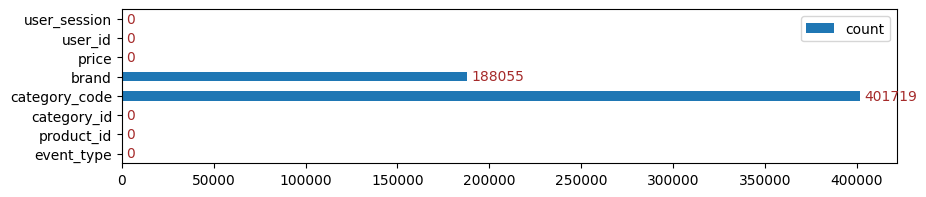

In [51]:
pdf_nulls = nb_extracted_records - pdf_summary.astype("int")
display(pdf_nulls)
chart = pdf_nulls.T.plot.barh(y="count", figsize=(10, 2))
labels = chart.bar_label(chart.containers[0], padding=3, color="brown")

**Categorical Fields**

Count of distinct values per categorical field

In [52]:
sdf_fact.select(
    [f.approx_count_distinct(field).alias(field)
        for field in ["product_id", "user_id", "user_session", "event_type", "category_code", "brand"]
    ]
).show()

+----------+-------+------------+----------+-------------+-----+
|product_id|user_id|user_session|event_type|category_code|brand|
+----------+-------+------------+----------+-------------+-----+
|     72525| 194811|      284604|         3|          124| 2339|
+----------+-------+------------+----------+-------------+-----+



List of most frequent categorical values per field

In [53]:
for field in ["event_type", "category_code", "brand"]:
    sdf_fact.groupBy(field) \
        .count() \
        .withColumnRenamed("count", "frequency") \
        .sort("frequency", ascending=False) \
        .limit(5) \
        .transpose() \
        .withColumnRenamed("key", field) \
        .show()

+----------+-----+--------+-------+
|event_type| cart|purchase|   view|
+----------+-----+--------+-------+
| frequency|16658|   19307|1208280|
+----------+-----+--------+-------+



+-------------+------------------+---------------------------+------------------+----------------------+
|category_code|computers.notebook|electronics.audio.headphone|electronics.clocks|electronics.smartphone|
+-------------+------------------+---------------------------+------------------+----------------------+
|    frequency|             35171|                      32712|             45432|                337246|
+-------------+------------------+---------------------------+------------------+----------------------+



+---------+------+------+-------+------+
|    brand| apple|huawei|samsung|xiaomi|
+---------+------+------+-------+------+
|frequency|128012| 34688| 145737| 84965|
+---------+------+------+-------+------+



### 3.2. Transformation

- Input : Fact Table with clean raw data from source file
- Process : transformation by feature engineering 
- Output : Feature Table with all required features

#### 3.2.1. Data Cleaning
**Duplicates**

Duplicates of the same user_session were found for different user_id's

In [54]:
# Get a list of sessions with duplicates
sdf_dupl_sessions = sdf_fact.select("user_session", "user_id") \
                    .distinct() \
                    .groupBy("user_session") \
                    .count() \
                    .filter(f.col("count") > 1)
list_dupl_sessions = list(sdf_dupl_sessions.toPandas()["user_session"])

**Impacted rows**

In [55]:
sdf_rows_to_delete = sdf_fact \
    .filter(f.col("user_session").isin(list_dupl_sessions)) \
    .select("user_session", "user_id")
sdf_rows_to_delete.sort("user_session").show(3)
nb_rows_to_delete = sdf_rows_to_delete.count()

+--------------------+---------+
|        user_session|  user_id|
+--------------------+---------+
|2759bd71-1333-434...|555463297|
|2759bd71-1333-434...|555463292|
|42a39e3a-1ed6-40d...|555570137|
+--------------------+---------+
only showing top 3 rows


**Chosen Solution**

- a) Analysis of the impact of a duplicate-session removal

In [56]:
perc_rows_to_delete = nb_rows_to_delete / nb_extracted_records * 100
print(f"{nb_rows_to_delete} rows with duplicated user_session values.") 
print(f"That represents {perc_rows_to_delete:.4f}%.")

# 0.0034% for 1.2M records

42 rows with duplicated user_session values.
That represents 0.0034%.


- b) **Decision taken**
 
Since the percentage of duplicate session records is very low, we will remove them from the dataset to avoid calculation errors

In [57]:
sdf_fact = sdf_fact.filter(~f.col("user_session").isin(list_dupl_sessions))

#### 3.2.2. Fact Table

In [58]:
# Store sdf_fact in cache (executes previous steps only once for 2 branches)
sdf_fact.persist()

# Records Count
print_nb_rows = lambda sdf_x, text : print(f"{sdf_x.count():,} rows {text}")
print_nb_rows(sdf_fact, "before transformation")

1,244,203 rows before transformation


#### 3.2.3. Feature Engineering
The expected output fields are grouped according to the key source fields required for their calculation:
* a) Attributes and features per product
* b) Features per session
* c) Features per product per session

A mapping matrix for each group follows, showing the dependence of each feature on the input fields

##### a) Attributes and features per product
<small>

| Output Field \ Input Field | Description | event time | event type | product id | category id | category_code, brand, price | user id | user session |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | 
| **product_id, category_code, brand, price** | Product details | | |X| |X| | |
| **purchased** | True if the product was purchased by the user during his session. | |"purchase"|X| | | |X|
| **num_views _product** | Total views for this product during the session. | |"view"|X| | | |X|

</small>

In [59]:
# Get identifier "product_id" & product attributes "category_code", "brand" & "price"
sdf_temp = sdf_fact \
    .filter(f.col("event_type").isin(["purchase", "view"])) \
    .select("product_id", "category_code", "brand", "price", "event_type", "user_session") \

# Get feature "purchased"
was_purchased = (f.col("event_type") == "purchase")
f_detect_purchase = f.max(was_purchased.cast("int"))  # max() flags if an event occurred

# Get feature "num_views_product"
was_viewed = (f.col("event_type") == "view")
f_count_views = f.sum(was_viewed.cast("int"))  # sum() counts event occurencies

# Get table "per_product"
sdf_per_product = sdf_temp \
    .groupBy("product_id", "category_code", "brand", "price", "user_session") \
    .agg(
        f_detect_purchase.alias("purchased"),
        f_count_views.alias("num_views_product")
    )

Check results

In [60]:
print_nb_rows(sdf_fact, "in input table")
print_nb_rows(sdf_per_product, "in table 'Feature per product'")
sdf_per_product.show(3)

1,244,203 rows in input table


837,664 rows in table 'Feature per product'


+----------+--------------------+-----+------+--------------------+---------+-----------------+
|product_id|       category_code|brand| price|        user_session|purchased|num_views_product|
+----------+--------------------+-----+------+--------------------+---------+-----------------+
|   6200547|appliances.enviro...|oasis| 49.81|1865d0ee-1f9b-4c7...|        0|                1|
|   1005115|electronics.smart...|apple|975.57|961ff93c-0af2-431...|        0|                1|
|   1801542|electronics.video.tv|   lg|486.24|22276094-f9ce-4e4...|        0|               13|
+----------+--------------------+-----+------+--------------------+---------+-----------------+
only showing top 3 rows


##### b) Features per session
<small>

| Output Field \ Input Field | Description | event time | event type | product id | category id | category_code, brand, price | user id | user session |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **num_views _session** | Total unique products viewed during the session. | |"view"|X| | | |X|
| **start_time** | Hour and minute the session began. |X| | | | | |X|
| **start_weekday** | Day of the week the session began. |X| | | | | |X|
| **duration** | Total session duration in seconds. |X| | | | | |X|
| **num_prev _sessions** | Count of the user's previous sessions. |X| | | | |X|X|

</small>

**b.1) Aggregated Features**

In [61]:
# Get feature "num_views_session"
f_count_unique_viewed_products = \
    f.count_distinct(  # count of distinct products viewed per session
        f.when(was_viewed, f.col("product_id"))
    )

# Get temporary feature "temp_start_dt"
f_temp_start_dt = f.min("event_time")

# Get temporary feature "temp_end_dt"
f_temp_end_dt = f.max("event_time")

# Get temporary table "temp_per_session"
sdf_temp = sdf_fact \
    .groupBy("user_session", "user_id") \
    .agg(
        f_count_unique_viewed_products.alias("num_views_session"),
        f_temp_start_dt.alias("temp_start_dt"),
        f_temp_end_dt.alias("temp_end_dt")
    )

Check results

In [62]:
print_nb_rows(sdf_fact, "in input table")
print_nb_rows(sdf_temp, "in table 'temp per session'")
sdf_temp.show(3)

1,244,203 rows in input table


268,727 rows in table 'temp per session'


+--------------------+---------+-----------------+-------------------+-------------------+
|        user_session|  user_id|num_views_session|      temp_start_dt|        temp_end_dt|
+--------------------+---------+-----------------+-------------------+-------------------+
|727a08f9-c385-443...|537934856|                1|2019-10-01 04:08:55|2019-10-01 04:08:55|
|5ed0d440-f23b-469...|552376713|               17|2019-10-01 06:18:20|2019-10-01 06:43:05|
|48246c5c-cf43-472...|540873367|                4|2019-10-01 06:48:21|2019-10-01 06:48:50|
+--------------------+---------+-----------------+-------------------+-------------------+
only showing top 3 rows


**b.2) Derived & Window-Aggregated Features**

3 derived features from an existing field and 1 window-aggregated.

A **window aggregation** allows for cummulative calculation on previous records.

For example, the count of previous records sorted by time where a target field matches the current record's value.

<small>

    # Step 1. Define the window frame
        period = Window \
            .partitionBy(target_field) \
            .orderBy(time_field) \
            .rowsBetween(lower_bound, upper_bound offset)
    # Step 2. Define a cummulative function applied to the window
        f_cummul = f.count(record_id).over(period)
    # Step 3. Append a column 
        sdf_x = sdf_y.withColumn(new_field, f_cummul)

</small>

In [63]:
# Get feature "start_time"
f_start_time = f.date_format(f.col("temp_start_dt"), "HH:mm")

# Get feature "start_weekday"
f_start_weekday = f.date_format(f.col("temp_start_dt"), "EEEE")

# Get feature "duration"
f_duration = f.col("temp_end_dt").cast("long") - f.col("temp_start_dt").cast("long")

# Get feature "num_prev_sessions" for a given user
period_before_current_session = Window \
    .partitionBy("user_id") \
    .orderBy("temp_start_dt") \
    .rowsBetween(Window.unboundedPreceding, -1) # excludes current row
f_num_prev_sessions = f.count("user_session").over(period_before_current_session)

# Get table "Features per session"
sdf_per_session = sdf_temp \
    .withColumn("start_time", f_start_time) \
    .withColumn("start_weekday", f_start_weekday) \
    .withColumn("duration", f_duration) \
    .withColumn("num_prev_sessions", f_num_prev_sessions
)

Check results

In [64]:
print_nb_rows(sdf_temp, "in input table")
print_nb_rows(sdf_per_session, "in table 'Features per session'")
sdf_per_session.show(3)

268,727 rows in input table


268,727 rows in table 'Features per session'


+--------------------+---------+-----------------+-------------------+-------------------+----------+-------------+--------+-----------------+
|        user_session|  user_id|num_views_session|      temp_start_dt|        temp_end_dt|start_time|start_weekday|duration|num_prev_sessions|
+--------------------+---------+-----------------+-------------------+-------------------+----------+-------------+--------+-----------------+
|91769fdf-461b-4e4...|244951053|                1|2019-10-01 08:47:35|2019-10-01 08:48:28|     08:47|      Tuesday|      53|                0|
|0051531b-c007-442...|292071852|                1|2019-10-01 17:06:51|2019-10-01 17:06:51|     17:06|      Tuesday|       0|                0|
|d146126f-ce44-48d...|293291933|                4|2019-10-01 18:58:32|2019-10-01 19:03:11|     18:58|      Tuesday|     279|                0|
+--------------------+---------+-----------------+-------------------+-------------------+----------+-------------+--------+-----------------+

##### c) Features per product per session

<small>

| Output Field \ Input Field | Description | event time | event type | product id | category id | category_code, brand, price | user id | user session |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **num_prev _product_views** | Count of previous views for this specific product across past sessions. |X|X|X| | | |X|

</small>

**c.1) Join Table**

The calculation of this field is based on fields from the join of tables "per_product" and "per_session".

In [65]:
sdf_features = sdf_per_product \
    .join(sdf_per_session, "user_session", "inner")
print_nb_rows(sdf_features, "after join of 2 tables")
sdf_features.show(3)

837,664 rows after join of 2 tables


+--------------------+----------+--------------------+--------+-------+---------+-----------------+---------+-----------------+-------------------+-------------------+----------+-------------+--------+-----------------+
|        user_session|product_id|       category_code|   brand|  price|purchased|num_views_product|  user_id|num_views_session|      temp_start_dt|        temp_end_dt|start_time|start_weekday|duration|num_prev_sessions|
+--------------------+----------+--------------------+--------+-------+---------+-----------------+---------+-----------------+-------------------+-------------------+----------+-------------+--------+-----------------+
|00016bb9-b50d-4bc...|  12300393|construction.tool...|    NULL|   39.1|        0|                2|523769618|                1|2019-10-01 09:51:44|2019-10-01 09:52:14|     09:51|      Tuesday|      30|                0|
|0001c1b8-85f4-46c...|  44500040|                NULL|omabelle|1686.02|        0|                1|512864803|           

**c.2) Aggregated Features**

The feature _`num_prev_product_views`_ represents the total number of views of the current product across all previous sessions but it wasn't clear by whom: the same user or any user. The customer was consulted and he stated that it's by the same user, which makes more sense for UX analysis.

In [66]:
# Period P of sessions previous to current one
period_before_current_session = Window \
    .partitionBy("product_id", "user_id") \
    .orderBy("temp_start_dt") \
    .rowsBetween(Window.unboundedPreceding, -1)  # omit current row

# Get feature "num_prev_product_views" (# of views of current product during P)
f_num_prev_product_views = f.coalesce(
    f.sum("num_views_product").over(period_before_current_session),
    f.lit(0)  # replace Null by 0
)

# Get table "Features_per_product_per_session"
sdf_features = sdf_features \
    .withColumn(
        "num_prev_product_views",
        f_num_prev_product_views
    )

**Verify Results**

Check counts for the most viewed product by the same user.

- Get Top tuple (user, product)

In [67]:
sdf_top = sdf_features.groupBy("user_id", "product_id") \
    .count() \
    .sort("count", ascending=False) \
    .limit(1)
sdf_top.show(3)

top_user_id, top_product_id, count = sdf_top.first()

+---------+----------+-----+
|  user_id|product_id|count|
+---------+----------+-----+
|512478069|  28401176|   18|
+---------+----------+-----+



- Check counts for this tuple

In [68]:
sdf_features \
    .filter(f.col("product_id") == top_product_id) \
    .filter(f.col("user_id") == top_user_id) \
    .select("num_prev_sessions", "num_views_product",
            "num_prev_product_views", "start_time", "temp_start_dt") \
    .show()

+-----------------+-----------------+----------------------+----------+-------------------+
|num_prev_sessions|num_views_product|num_prev_product_views|start_time|      temp_start_dt|
+-----------------+-----------------+----------------------+----------+-------------------+
|                0|                2|                     0|     02:28|2019-10-01 02:28:32|
|                1|                4|                     2|     02:29|2019-10-01 02:29:40|
|                2|                1|                     6|     02:40|2019-10-01 02:40:31|
|                3|                1|                     7|     02:40|2019-10-01 02:40:56|
|                4|                1|                     8|     02:43|2019-10-01 02:43:03|
|                5|                2|                     9|     02:50|2019-10-01 02:50:22|
|                6|                3|                    11|     02:51|2019-10-01 02:51:45|
|                7|                2|                    14|     03:08|2019-10-0

- The values in "num_prev_product_views" are correct according to fields "num_views_product" and "start_time".

#### 3.2.4 Feature Table

Non-expected output fields removal: temporary features and non expected attributes are dropped

In [69]:
sdf_features = sdf_features.drop("temp_start_dt", "temp_end_dt") #, "user_id")

The Feature Table contains the 13 expected output fields. 

In [70]:
print_nb_rows(sdf_features, "in 'Feature Table'")
sdf_features.show(3)
print("***** Transformation complete *****")

837,664 rows in 'Feature Table'


+--------------------+----------+--------------------+-----+------+---------+-----------------+---------+-----------------+----------+-------------+--------+-----------------+----------------------+
|        user_session|product_id|       category_code|brand| price|purchased|num_views_product|  user_id|num_views_session|start_time|start_weekday|duration|num_prev_sessions|num_prev_product_views|
+--------------------+----------+--------------------+-----+------+---------+-----------------+---------+-----------------+----------+-------------+--------+-----------------+----------------------+
|4a3656f4-47d8-4d5...|   1001588|electronics.smart...|meizu| 128.3|        1|                4|513568790|                2|     15:57|      Tuesday|    1366|                0|                     0|
|a521435c-5869-4a6...|   1001588|electronics.smart...|meizu| 128.3|        0|                1|513568790|                5|     20:05|      Tuesday|     503|                1|                     4|
|a287

### 3.3. Load
Writing the "Feature Table" to the output folder in CSV format.

In [71]:
# Force output to only 1 file with .coalesce()
# Replace existing data in 'overwrite' mode
sdf_features \
    .coalesce(1) \
    .write.mode("overwrite") \
    .csv(OUTPUT_PATH, header=True)

print(f"Data successfully exported to: {OUTPUT_PATH}")

Data successfully exported to: ../../data/processed/prototype_output


Check files loading

In [72]:
# Basic check of folder contents
if os.path.exists(OUTPUT_PATH):
    print("Output folder exists.")
    files = os.listdir(OUTPUT_PATH)
    print(f"Generated files:\n-  {"\n-  ".join(files)}")
else:
    print("Error: Output folder was not created.")

Output folder exists.
Generated files:
-  part-00000-5a60e0c7-2d2f-4518-9667-fb27d745499a-c000.csv
-  _SUCCESS
-  ._SUCCESS.crc
-  .part-00000-5a60e0c7-2d2f-4518-9667-fb27d745499a-c000.csv.crc


## 4. End Spark session

In [30]:
spark.stop()

## 5. Annex : Memory Storage
- Get local names of Spark DataFrames cached in cluster's memory.

In [ ]:
cached_sdf_names = [key for key, val in globals().items() \
                    if isinstance(val, DataFrame) \
                        and key != "DataFrame" \
                        and val.is_cached
                    ]

print(f"Cached Spark DataFrames in cluster memory: {cached_sdf_names}")

Cached Spark DataFrames in cluster memory: ['sdf_fact', 'sdf_data']


- Check Spark DataFrames stored as JVM Spark RDD's in Cluster's memory. 
  
Cf. http://localhost:4040/storage/

<img src="../docs/Local_Spark_Storage_for_nb_prototype.png" width="50%">